# Сравнительный анализ Европы и Азии

**Проект:** Анализ международной образовательной мобильности (2000–2024).

## Задачи

- Оценка динамики числа студентов из России в Европе и Азии.
- Визуализация динамики по странам.
- Анализ структуры мобильности по типу образовательных направлений.

## Данные
Промежуточная агрегированная таблица countries.xlsx, подготовленная на этапе EDA.

## Выбор стран для анализа

Для анализа выделены две группы стран:
- пять европейских стран-лидеров по числу студентов из России за весь период (Германия, Чехия, Франция, Великобритания, Финляндия);
- пять азиатских стран-лидеров по этому показателю (Казахстан, Армения, Киргизия, Турция, Республика Корея).

Важно отметить, что США, также занимающие высокие позиции по числу российских студентов, не были рассмотрены в этом проекте. Анализ Северной Америки может стать предметом дальнейших исследований. Кроме того, из данного анализа была исключена Украина: высокие показатели мобильности по этой стране могут быть связаны с особенностями сбора и учета данных.

Выбранные для анализа страны были разделены на три типа образовательных направлений:

1.	Global education hubs – страны с высокой международной привлекательностью, глобальные образовательные центры.  
2.	Regional education hubs – страны, являющиеся важными образовательными центрами на региональном уровне.  
3.	Post-Soviet space – страны постсоветского пространства со своими особенностями образовательной мобильности, на которую влияют исторические и языковые связи между странами.  


## Региональная динамика и типы образовательных направлений

In [1]:
import pandas as pd
countries=pd.read_excel('../data/processed/countries.xlsx')

countries.head(22)

,Страна,Регион,Число студентов из РФ,"Доля страны, %"
0,Germany,Europe,123770,13.06
1,Czechia,Europe,79907,8.43
2,France,Europe,76612,8.08
3,United Kingdom,Europe,69804,7.37
4,United States,North America,49296,5.20
5,Ukraine,Europe,47199,4.98
6,Finland,Europe,42314,4.46
7,Kazakhstan,Asia,39012,4.12
8,Belarus,Europe,35264,3.72
9,Italy,Europe,33592,3.54


In [2]:
selected=['Germany', 
               'Czechia', 
               'France', 
               'United Kingdom', 
               'Finland', 
               'Kazakhstan', 
               'Armenia', 
               'Kyrgyzstan', 
               'Türkiye', 
               'Korea, Republic of']

countries_sel=countries[countries['Страна'].isin(selected)].reset_index(drop=True)
countries_sel

,Страна,Регион,Число студентов из РФ,"Доля страны, %"
0,Germany,Europe,123770,13.06
1,Czechia,Europe,79907,8.43
2,France,Europe,76612,8.08
3,United Kingdom,Europe,69804,7.37
4,Finland,Europe,42314,4.46
5,Kazakhstan,Asia,39012,4.12
6,Armenia,Asia,27064,2.86
7,Kyrgyzstan,Asia,26205,2.77
8,Türkiye,Asia,24055,2.54
9,"Korea, Republic of",Asia,9831,1.04


In [3]:
countries_sel['Доля страны, %'].sum()

np.float64(54.73)

In [4]:
hub_type={'Germany':'Global education hub', 
               'Czechia':'Regional education hub', 
               'France':'Global education hub', 
               'United Kingdom':'Global education hub', 
               'Finland':'Regional education hub', 
               'Kazakhstan':'Post-Soviet space', 
               'Armenia':'Post-Soviet space', 
               'Kyrgyzstan':'Post-Soviet space', 
               'Türkiye':'Regional education hub', 
               'Korea, Republic of':'Regional education hub'}

countries_sel['Тип направления']=countries_sel['Страна'].map(hub_type)

countries_sel

,Страна,Регион,Число студентов из РФ,"Доля страны, %",Тип направления
0,Germany,Europe,123770,13.06,Global education hub
1,Czechia,Europe,79907,8.43,Regional education hub
2,France,Europe,76612,8.08,Global education hub
3,United Kingdom,Europe,69804,7.37,Global education hub
4,Finland,Europe,42314,4.46,Regional education hub
5,Kazakhstan,Asia,39012,4.12,Post-Soviet space
6,Armenia,Asia,27064,2.86,Post-Soviet space
7,Kyrgyzstan,Asia,26205,2.77,Post-Soviet space
8,Türkiye,Asia,24055,2.54,Regional education hub
9,"Korea, Republic of",Asia,9831,1.04,Regional education hub


In [5]:
df=pd.read_csv('../data/processed/student_mobility_clean.csv')

df_sel=df.merge(countries_sel[['Страна','Регион','Тип направления']],
                on='Страна',
                how='inner')

df_sel.to_excel('../data/processed/countries_sel_2000_2024.xlsx', index=False)

df_sel

,Страна,Год,Число студентов из РФ,Регион,Тип направления
0,Armenia,2003,290,Asia,Post-Soviet space
1,Armenia,2004,662,Asia,Post-Soviet space
2,Armenia,2005,477,Asia,Post-Soviet space
3,Armenia,2006,680,Asia,Post-Soviet space
4,Armenia,2007,828,Asia,Post-Soviet space
...,...,...,...,...,...
220,Türkiye,2019,1409,Asia,Regional education hub
221,Türkiye,2020,1439,Asia,Regional education hub
222,Türkiye,2021,1648,Asia,Regional education hub
223,Türkiye,2022,1711,Asia,Regional education hub


In [6]:
df_sel_reg=df_sel.groupby(['Регион', 'Год'])['Число студентов из РФ'].sum().reset_index()
df_sel_reg.head()

,Регион,Год,Число студентов из РФ
0,Asia,2000,1809
1,Asia,2001,2669
2,Asia,2002,1191
3,Asia,2003,3193
4,Asia,2004,3944


In [7]:
df_sel_reg_pivot=df_sel_reg.pivot(index='Год', columns='Регион', values='Число студентов из РФ')
df_sel_reg_pivot.head()

Регион,Asia,Europe
Год,,
2000,1809,3277
2001,2669,3952
2002,1191,4499
2003,3193,5522
2004,3944,6022


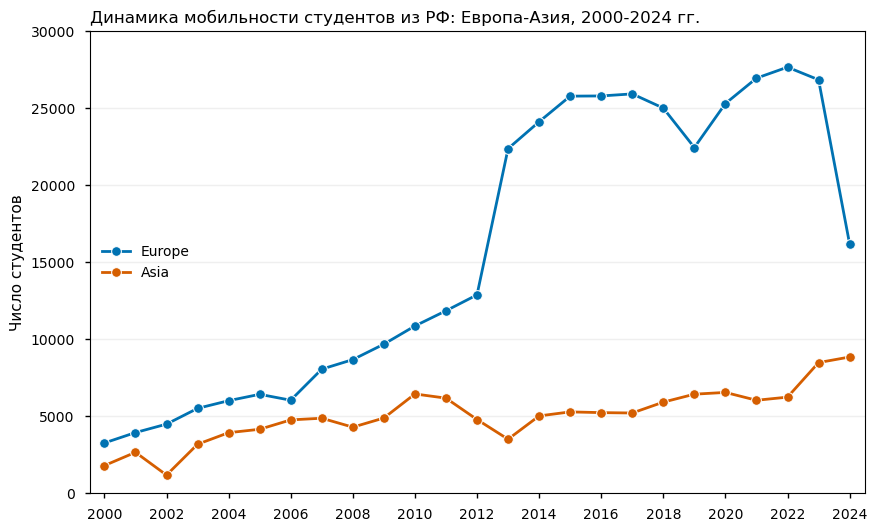

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.style.use('seaborn-v0_8-notebook')

europe_color='#0072B2'
asia_color='#D55E00'

plt.figure(figsize=(10,6))

ax=sns.lineplot(data=df_sel_reg, 
                  x='Год',
                  y='Число студентов из РФ',
                  marker='o',
                  hue='Регион',
                  hue_order=['Europe','Asia'],
                  palette=[europe_color,asia_color],
                  linewidth=2)

ax.set_title('Динамика мобильности студентов из РФ: Европа-Азия, 2000-2024 гг.', loc='left')
ax.set_xlabel('')
ax.set_ylabel('Число студентов')

ax.set_xticks(range(2000, 2025, 2))
ax.set_xticklabels(range(2000, 2025, 2), size=10)
ax.set_ylim(0,30000)
ax.margins(x=0.02)

ax.legend(title=None,loc='center left',frameon=False)

ax.grid(True, axis='y', alpha=0.2)

plt.savefig('../visuals/03_europe_asia_2000_2024.png', dpi=150, bbox_inches='tight')

plt.show()

## Динамика по странам

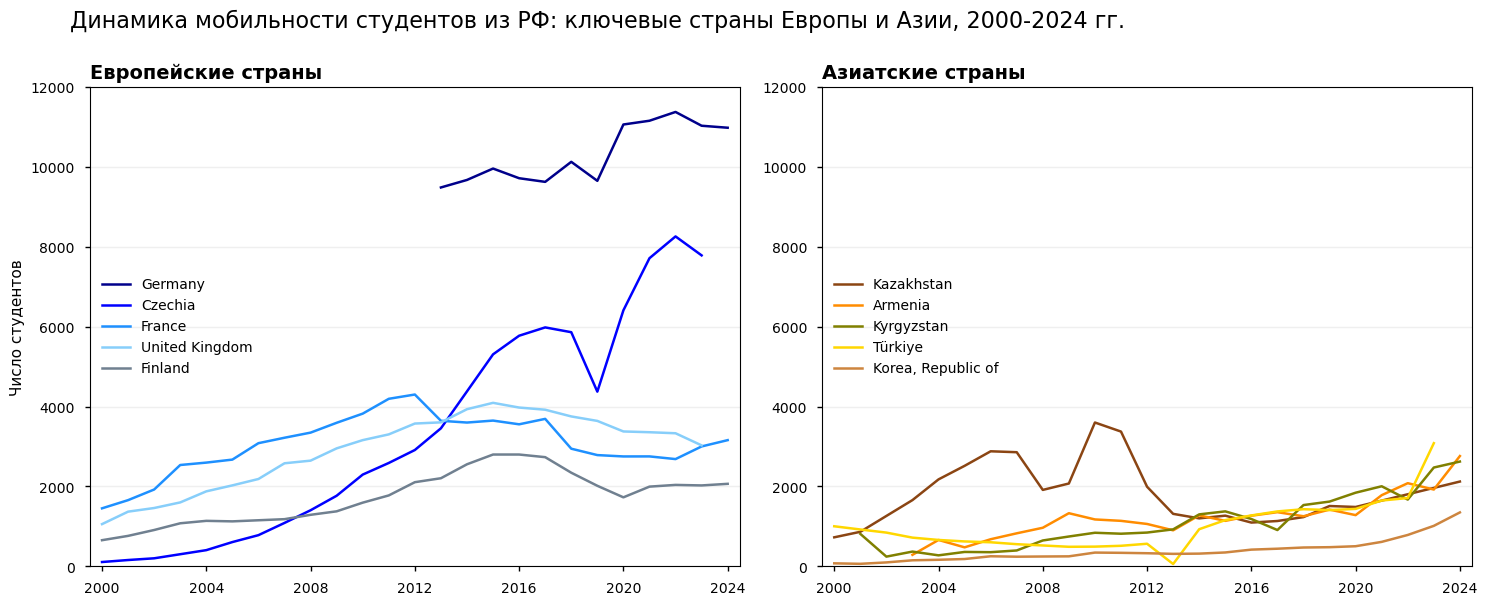

In [9]:
europe=['Germany', 'Czechia', 'France', 'United Kingdom', 'Finland']
asia=['Kazakhstan', 'Armenia', 'Kyrgyzstan', 'Türkiye', 'Korea, Republic of']

df_sel_europe=df_sel[df_sel['Страна'].isin(europe)]
df_sel_asia=df_sel[df_sel['Страна'].isin(asia)]

europe_palette=['darkblue', 'blue', 'dodgerblue', 'lightskyblue', 'slategrey']
asia_palette=['saddlebrown', 'darkorange', 'olive', 'gold', 'peru']

fig=plt.figure(figsize=(15, 6))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)

sns.lineplot(data=df_sel_europe,
             x='Год',
             y='Число студентов из РФ',
             hue='Страна',
             hue_order=europe,
             palette=europe_palette,
             linewidth=1.8,
            ax=ax1)

ax1.set_title('Европейские страны', fontsize=14, fontweight='bold', loc='left')
ax1.set_xlabel('')
ax1.set_ylabel('Число студентов')
ax1.set_xticks(range(2000, 2025, 4))
ax1.set_ylim(0,12000)
ax1.margins(x=0.02)
ax1.grid(True, axis='y', alpha=0.2)
ax1.legend(title=None, loc='center left', frameon=False)

sns.lineplot(data=df_sel_asia,
             x='Год',
             y='Число студентов из РФ',
             hue='Страна',
             hue_order=asia,
             palette=asia_palette,
             linewidth=1.8,
            ax=ax2)

ax2.set_title('Азиатские страны', fontsize=14, fontweight='bold', loc='left')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_xticks(range(2000, 2025, 4))
ax2.set_ylim(0,12000)
ax2.margins(x=0.02)
ax2.grid(True, axis='y', alpha=0.2)
ax2.legend(title=None, loc='center left', frameon=False)

fig.suptitle('Динамика мобильности студентов из РФ: ключевые страны Европы и Азии, 2000-2024 гг.', 
             size=16, x=0.05, ha='left', y=1.001)

plt.tight_layout()

plt.savefig('../visuals/03_top_10_europe_asia_2000_2024.png', dpi=150, bbox_inches='tight')

plt.show()

## Структура мобильности по типу направлений

In [10]:
df_sel.head()

,Страна,Год,Число студентов из РФ,Регион,Тип направления
0,Armenia,2003,290,Asia,Post-Soviet space
1,Armenia,2004,662,Asia,Post-Soviet space
2,Armenia,2005,477,Asia,Post-Soviet space
3,Armenia,2006,680,Asia,Post-Soviet space
4,Armenia,2007,828,Asia,Post-Soviet space


In [11]:
df_sel_types=df_sel.groupby(['Тип направления','Год'])['Число студентов из РФ'].sum().reset_index()

df_sel_types_pivot=df_sel_types.pivot(index='Год',
                                      columns='Тип направления',
                                      values='Число студентов из РФ')
df_sel_types_pivot=df_sel_types_pivot[['Global education hub', 'Regional education hub', 'Post-Soviet space']]

df_sel_types_pivot.head()

Тип направления,Global education hub,Regional education hub,Post-Soviet space
Год,,,
2000,2511,1847,728
2001,3028,1913,1680
2002,3385,2060,245
2003,4138,2257,2320
2004,4475,2375,3116


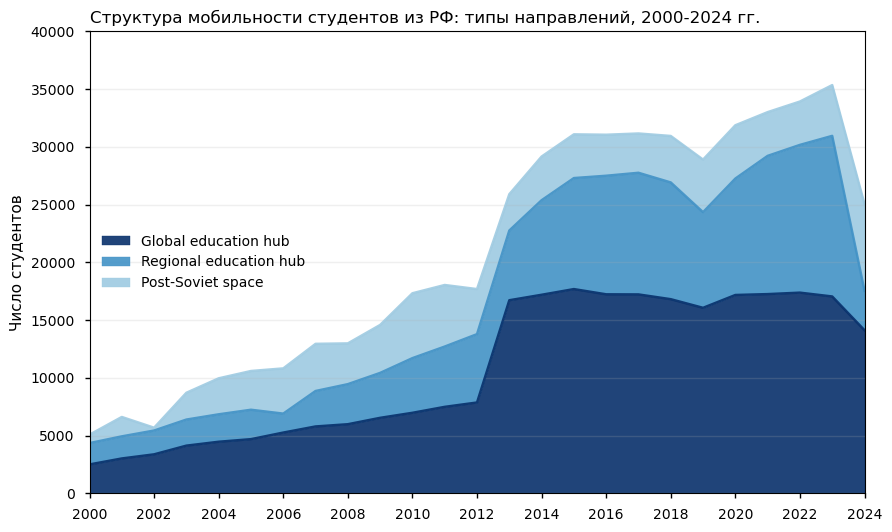

In [12]:
colors=['#08306B', '#4292C6', '#9ECAE1']

ax=df_sel_types_pivot.plot.area(figsize=(10,6), color=colors, alpha=0.9)

ax.set_xlabel('')
ax.set_ylabel('Число студентов')
ax.set_title('Cтруктура мобильности студентов из РФ: типы направлений, 2000-2024 гг.', loc='left')
ax.set_xticks(range(2000,2025,2))
ax.set_xticklabels(range(2000,2025,2), size=10)
ax.set_ylim(0,40000)
ax.grid(axis='y', alpha=0.2)
ax.legend(title=None,loc='center left',frameon=False)
ax.margins(x=0)

plt.savefig('../visuals/03_destination_types_2000_2024.png', dpi=150, bbox_inches='tight')

plt.show()


## Тепловая карта мобильности по странам

In [13]:
df_heat=df_sel.pivot(index='Страна',
                       columns='Год',
                       values='Число студентов из РФ')

df_heat=df_heat.loc[df_heat.sum(axis=1).sort_values(ascending=False).index]
df_heat.head()

Год,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Страна,,,,,,,,,,,,,,,,,,,,,
Germany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9953.0,9711.0,9620.0,10121.0,9646.0,11055.0,11149.0,11369.0,11024.0,10974.0
Czechia,110.0,160.0,203.0,305.0,407.0,609.0,782.0,1088.0,1405.0,1768.0,...,5305.0,5771.0,5979.0,5859.0,4372.0,6407.0,7710.0,8255.0,7781.0,NaN
France,1453.0,1658.0,1924.0,2537.0,2597.0,2672.0,3083.0,3219.0,3347.0,3593.0,...,3648.0,3555.0,3691.0,2945.0,2785.0,2751.0,2752.0,2685.0,3001.0,3159.0
United Kingdom,1058.0,1370.0,1461.0,1601.0,1878.0,2027.0,2187.0,2580.0,2646.0,2953.0,...,4092.0,3974.0,3920.0,3752.0,3640.0,3376.0,3357.0,3331.0,3028.0,NaN
Finland,656.0,764.0,911.0,1079.0,1140.0,1127.0,NaN,1182.0,1291.0,1378.0,...,2799.0,2799.0,2733.0,2344.0,2017.0,1728.0,1996.0,2039.0,2026.0,2066.0


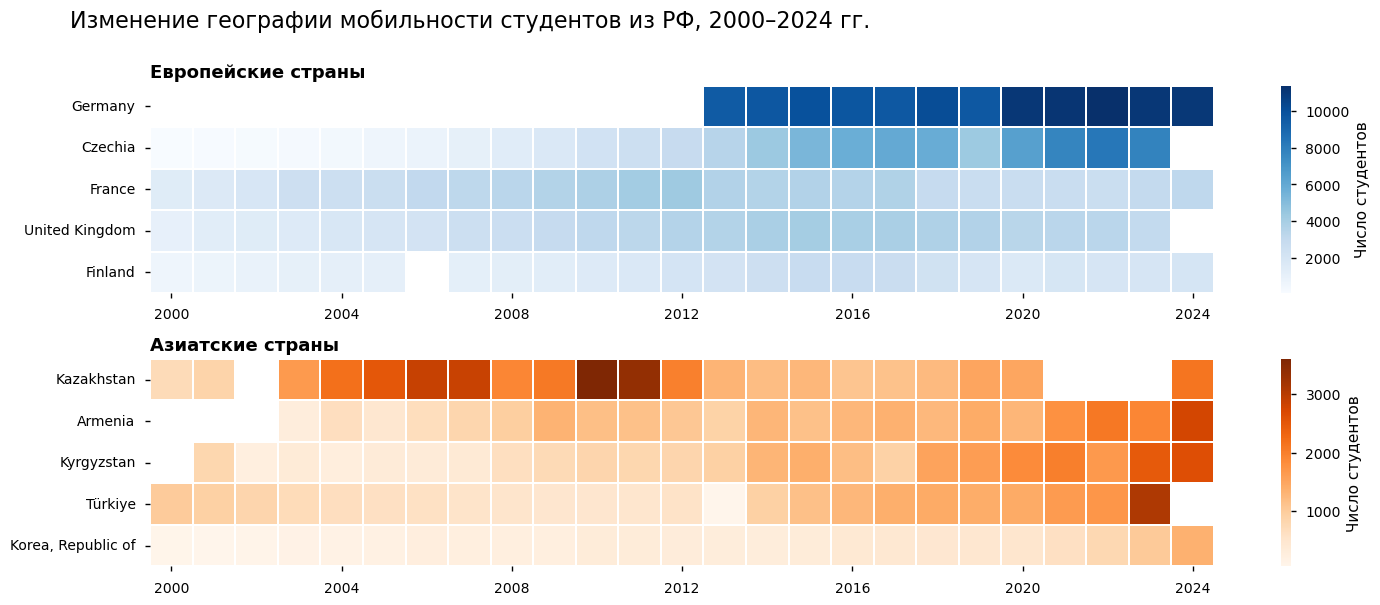

In [14]:
european_countries=['Germany', 'Czechia', 'France', 'United Kingdom', 'Finland']
asian_countries=['Kazakhstan', 'Armenia', 'Kyrgyzstan', 'Türkiye', 'Korea, Republic of']

df_heat_europe=df_heat.loc[european_countries]
df_heat_asia=df_heat.loc[asian_countries]

fig, (ax1, ax2)=plt.subplots(2, 1, figsize=(15, 6))

sns.heatmap(df_heat_europe,
            cmap='Blues',
            linewidths=0.3,
            linecolor='white',
            ax=ax1,
            cbar_kws={'label': 'Число студентов'})
ax1.set_title('Европейские страны', fontsize=13, fontweight='bold', loc='left')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_xticks([i+0.5 for i in range(0,len(df_heat_europe.columns),4)])
ax1.set_xticklabels(range(2000,2025,4))

sns.heatmap(df_heat_asia,
            cmap='Oranges',
            linewidths=0.3,
            linecolor='white',
            ax=ax2,
           cbar_kws={'label': 'Число студентов'})
ax2.set_title('Азиатские страны', fontsize=13, fontweight='bold', loc='left')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_xticks([i+0.5 for i in range(0,len(df_heat_asia.columns),4)])
ax2.set_xticklabels(range(2000,2025,4))

plt.suptitle('Изменение географии мобильности студентов из РФ, 2000–2024 гг.', fontsize=16, x=0.05, ha='left', y=1.001)

plt.tight_layout()

plt.savefig('../visuals/03_top_10_europe_asia_heatmap_2000_2024.png', dpi=150, bbox_inches='tight')

plt.show()

Цветовые шкалы для европейских и азиатских стран разные, поскольку диапазоны значений существенно различаются.

## Основные результаты

- С 2000 по 2024 гг. Европа остаётся ведущим направлением международной мобильности по числу студентов из России.
- Анализ структуры мобильности по типу образовательных направлений для десяти ведущих стран Европы и Азии показывает, что чаще всего студенты выбирали для обучения глобальные образовательные центры. Доля глобальных образовательных центров выросла с 45% в 2000–2012 гг. до 55% в 2013–2024 гг., доля региональных центров – с 27% до 31%. Доля стран постсоветского пространства сократилась с 28% до 14%.
- Страны постсоветского пространства показывают наиболее заметный рост входящей образовательной мобильности из России после 2023 года.